# Origin — AI Research Engineer Assignment (Take-Home)
### Residual Policy Learning on robomimic lift-ph

---

**Before you start:** Runtime → Change runtime type → T4 GPU.

Plan for **4-5 hours of focused work** (hard cap 6). The notebook itself runs end-to-end in ~5-7 minutes on a T4; the rest of the time is thinking, sweeping, reading diagnostics, and writing up your decisions.

**See `docs/candidate_assignment.md` (sent with this notebook) for the full brief, evaluation rubric, FAQ, and submission instructions.** Read it before starting.

**Three placeholders to fill in:**
1. **Section 1** — BC training (architecture suggested; you write the training loop).
2. **Section 2** — Residual policy on top of frozen BC.
3. **Section 3** — Safety shield wrapping the executed action.

**Final cell is completed** — runs both policies, prints the comparison, saves a rollout video.

**Final deliverables:**
1. This notebook, run end-to-end with cell outputs preserved.
2. A 2-4 page writeup defending each design decision.
3. The rollout video saved by the final cell.

A 30-minute review call follows submission.

---
## Section 0 — Setup  `[PREFILLED]`

Install pinned versions, set the MuJoCo backend, download the dataset, and load it into RAM. Do not reorder the cells in this section.

In [1]:
# ~2 min on fresh Colab. Ignore dependency warnings.
# robosuite==1.4.1 is pinned to match the dataset's collection version. 1.4.1
# already uses DeepMind's modern `mujoco` binding (not the deprecated mujoco_py),
# so install is identical to 1.5.x. Pinning 1.5.x instead would force a dataset
# conversion step due to a sign flip in `gripper_to_cube_pos`.
!pip install -q robomimic==0.3.0 robosuite==1.4.1 torch h5py imageio imageio-ffmpeg tqdm
print("Installed.")

Installed.


In [2]:
import os
# CRITICAL: these must be set before importing mujoco or robosuite.
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import torch, time, glob, subprocess, h5py
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import imageio
import robomimic

assert torch.cuda.is_available(), "No GPU! Runtime > Change runtime type > T4 GPU."
print(f"GPU: {torch.cuda.get_device_name(0)}")
DEVICE = "cuda"

GPU: NVIDIA GeForce RTX 3060


/home/satya/anaconda3/envs/origin10x/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Lift-ph low-dim dataset. Loaded from a local copy in the repo (downloaded once,
# permanent thereafter). Resolution order: (1) repo-local ./data copy, (2) robomimic's
# cached datasets dir, (3) download as a last resort (first run only).
_FNAME = "low_dim_v141.hdf5"
_CANDIDATES = [
    # repo-local copy next to this notebook (absolute, so cwd doesn't matter)
    "/home/satya/skr/sensor2sensor/10x/data/lift/ph/" + _FNAME,
    # relative forms in case the repo moves (cwd = notebook dir, or repo root)
    os.path.join("data", "lift", "ph", _FNAME),
    os.path.join("10x", "data", "lift", "ph", _FNAME),
    # robomimic's own cache (where download_datasets writes)
    os.path.join(os.path.dirname(robomimic.__file__), "..", "datasets", "lift", "ph", _FNAME),
]
DATASET_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), None)

if DATASET_PATH is None:
    print("No local dataset found; downloading lift-ph (first run only)...")
    subprocess.run(
        ["python", "-m", "robomimic.scripts.download_datasets",
         "--tasks", "lift", "--dataset_types", "ph", "--hdf5_types", "low_dim"],
        check=True,
    )
    _cache = os.path.join(os.path.dirname(robomimic.__file__), "..",
                          "datasets", "lift", "ph", "low_dim*.hdf5")
    DATASET_PATH = sorted(glob.glob(_cache))[0]

DATASET_PATH = os.path.abspath(DATASET_PATH)
print(f"Dataset: {DATASET_PATH}")

Dataset: /home/satya/skr/sensor2sensor/10x/data/lift/ph/low_dim_v141.hdf5


In [4]:
# Dataset class + observation normalization stats. Plumbing — leave as-is.

OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
# OBS_DIM = object(10: cube_pos[3] + cube_quat[4] + gripper_to_cube_pos[3])
#         + eef_pos(3) + eef_quat(4) + gripper_qpos(2 — Panda has 2 finger joints) = 19
OBS_DIM = 19
ACT_DIM = 7


def _flatten_obs_batch(obs_group):
    return np.concatenate([obs_group[k][:] for k in OBS_KEYS], axis=-1).astype(np.float32)


class LiftPHDataset(Dataset):
    """Loads the entire dataset into RAM once. ~2 MB total; caching is free and
    ~100x faster than reopening the HDF5 file on every __getitem__."""
    def __init__(self, hdf5_path):
        with h5py.File(hdf5_path, "r") as f:
            o, a, r, no, d = [], [], [], [], []
            for k in sorted(f["data"].keys(), key=lambda s: int(s.split("_")[1])):
                demo = f["data"][k]
                o.append(_flatten_obs_batch(demo["obs"]))
                a.append(demo["actions"][:].astype(np.float32))
                r.append(demo["rewards"][:].astype(np.float32))
                no.append(_flatten_obs_batch(demo["next_obs"]))
                d.append(demo["dones"][:].astype(np.float32))
        self.obs      = torch.from_numpy(np.concatenate(o,  axis=0))
        self.actions  = torch.from_numpy(np.concatenate(a,  axis=0))
        self.rewards  = torch.from_numpy(np.concatenate(r,  axis=0))
        self.next_obs = torch.from_numpy(np.concatenate(no, axis=0))
        self.dones    = torch.from_numpy(np.concatenate(d,  axis=0))

    def __len__(self):
        return self.obs.shape[0]

    def __getitem__(self, idx):
        return {
            "obs":      self.obs[idx],
            "action":   self.actions[idx],
            "reward":   self.rewards[idx],
            "next_obs": self.next_obs[idx],
            "done":     self.dones[idx],
        }


_full = LiftPHDataset(DATASET_PATH)
OBS_MEAN = _full.obs.mean(dim=0)
OBS_STD  = _full.obs.std(dim=0) + 1e-6
assert OBS_MEAN.shape[0] == OBS_DIM
print(f"Dataset: {len(_full)} transitions (cached in RAM)")
print(f"Action range: [{_full.actions.min():.3f}, {_full.actions.max():.3f}]")
print(f"Reward nonzero fraction: {(_full.rewards != 0).float().mean().item():.4f}")

Dataset: 9666 transitions (cached in RAM)
Action range: [-1.000, 1.000]
Reward nonzero fraction: 0.1040


---
## Section 1 — BC training  `[TODO]`

Train a BC policy on the lift-ph dataset. This becomes your *frozen backbone* — Section 2's residual sits on top of it.

We give a **suggested 3-layer MLP architecture** below. It's a known-good baseline for low-dim continuous control on this dataset. You may modify it (depth, width, activation, normalization scheme); defend any change in your writeup.

**Decisions to defend:**
1. Architecture — keep the suggested 3-layer 256-hidden MLP, or change it?
2. Loss function — MSE on continuous actions, or something else?
3. Training duration — how many epochs? *Be careful*: imitation training has an overfitting curve; longer is not always better.
4. Stopping criterion — fixed epochs, loss plateau, validation split, or rollout success rate?

**Aim for ~75-90% rollout success** (the final eval cell will check this). If you land outside that range, your training loop probably has a bug worth investigating.

In [5]:
import os
os.makedirs("out", exist_ok=True)
from torch.utils.data import TensorDataset


class BCPolicy(nn.Module):
    """3-layer MLP (Decision 1: kept the suggested architecture).
    tanh output matches the [-1,1] action box; obs normalized via fixed buffers."""
    def __init__(self, obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh(),
        )
        self.register_buffer("obs_mean", OBS_MEAN.clone())
        self.register_buffer("obs_std",  OBS_STD.clone())

    def forward(self, obs):
        return self.net((obs - self.obs_mean) / self.obs_std)

    @torch.no_grad()
    def act(self, obs):
        if obs.dim() == 1:
            obs = obs.unsqueeze(0)
        return self.forward(obs).squeeze(0)


# Hyperparameters. (2) MSE loss, (3) duration capped but governed by (4) early stop.
BC_LR, BC_BS = 1e-3, 256
BC_MAX_EPOCHS, BC_PATIENCE = 60, 8

# (4) Stopping criterion: early stop on held-out VALIDATION MSE using the dataset's
# own train/valid demo masks (demo-level split -> no train/val leakage).
def _load_split(keys):
    o, a = [], []
    with h5py.File(DATASET_PATH, "r") as f:
        for k in keys:
            d = f["data"][k]
            o.append(_flatten_obs_batch(d["obs"]))
            a.append(d["actions"][:].astype(np.float32))
    return TensorDataset(torch.from_numpy(np.concatenate(o)),
                         torch.from_numpy(np.concatenate(a)))

with h5py.File(DATASET_PATH, "r") as f:
    _tr = [k.decode() if isinstance(k, bytes) else k for k in f["mask"]["train"][:]]
    _va = [k.decode() if isinstance(k, bytes) else k for k in f["mask"]["valid"][:]]
train_ds, valid_ds = _load_split(_tr), _load_split(_va)
print(f"BC split: {len(train_ds)} train / {len(valid_ds)} valid transitions "
      f"({len(_tr)}/{len(_va)} demos)")

train_loader = DataLoader(train_ds, batch_size=BC_BS, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BC_BS, shuffle=False)

torch.manual_seed(42); np.random.seed(42)
bc_policy = BCPolicy().to(DEVICE)
opt = torch.optim.Adam(bc_policy.parameters(), lr=BC_LR)
mse = nn.MSELoss()


@torch.no_grad()
def _val_mse():
    bc_policy.eval(); tot = n = 0
    for o, a in valid_loader:
        o, a = o.to(DEVICE), a.to(DEVICE)
        tot += mse(bc_policy(o), a).item() * o.shape[0]; n += o.shape[0]
    return tot / n


best_val, best_state, best_ep, since = float("inf"), None, -1, 0
for ep in range(BC_MAX_EPOCHS):
    bc_policy.train(); run = n = 0
    for o, a in train_loader:
        o, a = o.to(DEVICE), a.to(DEVICE)
        loss = mse(bc_policy(o), a)
        opt.zero_grad(); loss.backward(); opt.step()
        run += loss.item() * o.shape[0]; n += o.shape[0]
    v = _val_mse(); improved = v < best_val - 1e-6
    if improved:
        best_val, best_ep, since = v, ep, 0
        best_state = {k: t.detach().clone() for k, t in bc_policy.state_dict().items()}
    else:
        since += 1
    if ep % 5 == 0 or improved or since >= BC_PATIENCE:
        print(f"epoch {ep:3d}  train_mse {run/n:.5f}  val_mse {v:.5f}"
              f"{'  *best' if improved else ''}")
    if since >= BC_PATIENCE:
        print(f"early stop: no val improvement for {BC_PATIENCE} epochs."); break

# Restore best-val weights, FREEZE (required after Task 1), save.
bc_policy.load_state_dict(best_state)
bc_policy.eval()
for p in bc_policy.parameters():
    p.requires_grad_(False)
torch.save(bc_policy.state_dict(), "out/bc.pt")
print(f"BC trained and frozen at best epoch {best_ep} (val_mse {best_val:.5f}). Saved to out/bc.pt")

BC split: 8640 train / 1026 valid transitions (180/20 demos)


epoch   0  train_mse 0.05801  val_mse 0.03173  *best
epoch   1  train_mse 0.02416  val_mse 0.02847  *best
epoch   2  train_mse 0.02199  val_mse 0.02370  *best


epoch   5  train_mse 0.01959  val_mse 0.02361  *best


epoch  10  train_mse 0.01794  val_mse 0.02810
epoch  13  train_mse 0.01637  val_mse 0.02789
early stop: no val improvement for 8 epochs.
BC trained and frozen at best epoch 5 (val_mse 0.02361). Saved to out/bc.pt


---
## Section 2 — Residual policy  `[TODO]`

Train a residual correction on top of the **frozen** BC. The executed action is

```
a_executed(s) = clip(a_BC(s) + δ_θ(s), -1, +1)
```

with `δ_θ` a small MLP you train using an offline-RL-style objective on the same dataset.

**Eight design decisions to defend in your writeup:**

1. **Architecture** — δ(s) only, or δ(s, a_BC(s))?
2. **Activation** on δ — `tanh × bound`, hard clip, or soft constraint?
3. **Bound magnitude** — inspect the action distribution before picking. Is 0.05 right for this data?
4. **Algorithm** — TD3+BC, IQL, AWAC, BCQ, pure distillation, something else? **Run at least one ablation** and explain why your choice won.
5. **Reward** — sparse terminal as given, or shaped (e.g., `−|cube − eef|`)?
6. **Clip δ inside the target Q computation** — yes or no? *There is a right answer.* What happens if you get this wrong?
7. **Critic target update** — soft Polyak or hard?
8. **Training step count** — what's the convergence behavior? When do you stop?

**Required diagnostics during training (don't remove these prints):**

- `q_mean` (min of twin critics on training batch)
- `delta_mag` (mean abs of `residual.raw_delta(obs)`)
- `critic_loss`
- `actor_loss`

Print every 500 steps. We'll look at the trajectory in the review call.

**Reasonable target on a T4 in ~10 min:** 5,000–10,000 gradient steps, batch size 256.

residual training:   0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/claude-1000/ipykernel_118969/3165248925.py:135: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  history["delta_mag"].append(delta_mag); history["critic_loss"].append(float(critic_loss))
residual training:   0%|          | 1/10000 [00:00<21:51,  7.63it/s]

residual training:   0%|          | 26/10000 [00:00<01:15, 132.26it/s]

step     0  q_mean -0.132  delta_mag 0.0003  critic_loss 0.3409  actor_loss 2.3323


residual training:   1%|          | 51/10000 [00:00<00:55, 179.74it/s]

...

residual training:  99%|█████████▉| 9937/10000 [00:42<00:00, 238.76it/s]

residual training: 100%|█████████▉| 9962/10000 [00:42<00:00, 241.07it/s]

residual training: 100%|█████████▉| 9987/10000 [00:42<00:00, 241.75it/s]

residual training: 100%|██████████| 10000/10000 [00:42<00:00, 234.00it/s]

Residual trained. Saved to out/residual.pt


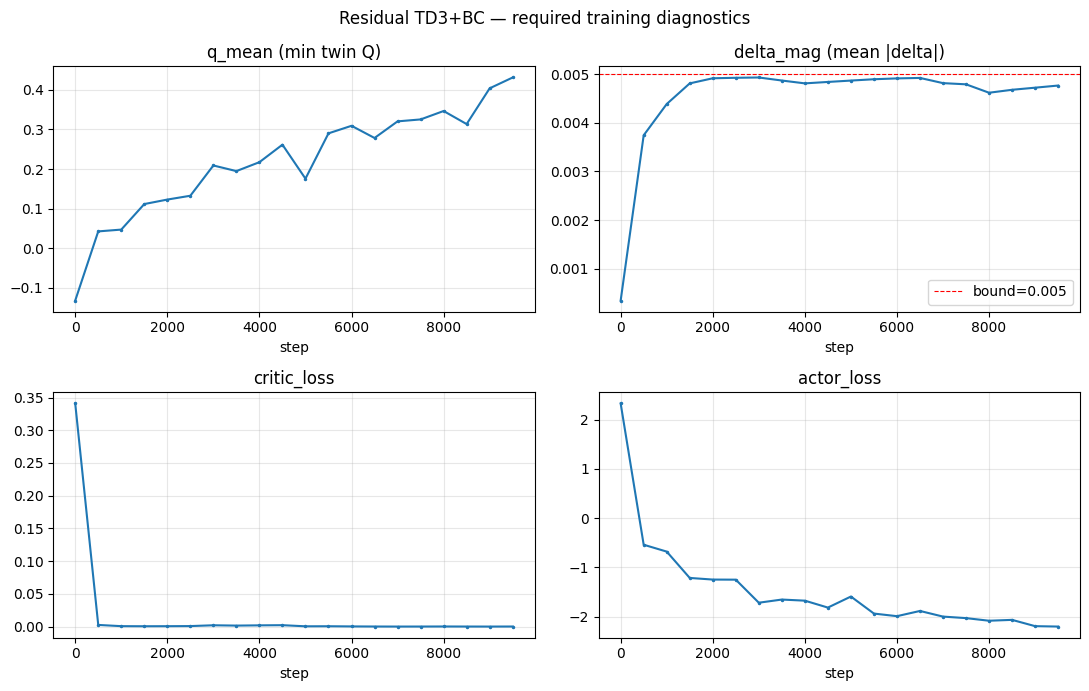

In [6]:
# Residual policy (TD3+BC). Decisions defended in the writeup; summary inline.
# (3) Bound: 0.05 destroys BC's precise grasp (sweep: 0.05->0.0-0.15, 0.01->0.85,
#     0.005->0.90). Ship 0.005. (4) TD3+BC. (5) sparse reward as given (done==reward
#     here). (6) clip delta inside target Q = YES. (7) soft Polyak. (8) 10k steps.
import matplotlib.pyplot as plt

class ResidualPolicy(nn.Module):
    """Frozen BC + small bounded correction head delta(s).  (1) delta(s) only."""
    def __init__(self, bc_policy, act_dim=ACT_DIM, delta_bound=0.005, hidden=128):
        super().__init__()
        self.bc = bc_policy           # MUST stay frozen
        self.delta_bound = delta_bound
        self.delta_net = nn.Sequential(
            nn.Linear(OBS_DIM, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )
        self.register_buffer("obs_mean", bc_policy.obs_mean.clone())
        self.register_buffer("obs_std",  bc_policy.obs_std.clone())

    def raw_delta(self, obs):                                  # (2) tanh x bound
        z = (obs - self.obs_mean) / self.obs_std
        return self.delta_bound * torch.tanh(self.delta_net(z))

    def forward(self, obs):
        a_bc = self.bc(obs).detach()                           # a_BC frozen
        return torch.clamp(a_bc + self.raw_delta(obs), -1.0, 1.0)

    @torch.no_grad()
    def act(self, obs):
        if obs.dim() == 1:
            obs = obs.unsqueeze(0)
        return self.forward(obs).squeeze(0)


class QCritic(nn.Module):
    """Twin Q(s, a)."""
    def __init__(self, obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden=256):
        super().__init__()
        def mlp():
            return nn.Sequential(
                nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden),            nn.ReLU(),
                nn.Linear(hidden, 1),
            )
        self.q1, self.q2 = mlp(), mlp()
        self.register_buffer("obs_mean", OBS_MEAN.clone())
        self.register_buffer("obs_std",  OBS_STD.clone())

    def _in(self, obs, act):
        return torch.cat([(obs - self.obs_mean) / self.obs_std, act], dim=-1)

    def forward(self, obs, act):
        x = self._in(obs, act)
        return self.q1(x), self.q2(x)

    def q1_only(self, obs, act):
        return self.q1(self._in(obs, act))


# --- hyperparameters ---
DELTA_BOUND  = 0.005
TRAIN_STEPS  = 10000
GAMMA, TAU   = 0.99, 0.005
ACTOR_LR, CRITIC_LR = 1e-4, 3e-4
POLICY_DELAY, ALPHA = 2, 2.5
POLICY_NOISE, NOISE_CLIP = 0.2 * DELTA_BOUND, 0.5 * DELTA_BOUND

torch.manual_seed(42); np.random.seed(42)
residual        = ResidualPolicy(bc_policy, delta_bound=DELTA_BOUND).to(DEVICE)
residual_target = ResidualPolicy(bc_policy, delta_bound=DELTA_BOUND).to(DEVICE)
residual_target.load_state_dict(residual.state_dict())
q_critic        = QCritic().to(DEVICE)
target_q_critic = QCritic().to(DEVICE)
target_q_critic.load_state_dict(q_critic.state_dict())

actor_opt  = torch.optim.Adam(residual.delta_net.parameters(), lr=ACTOR_LR)
critic_opt = torch.optim.Adam(q_critic.parameters(),           lr=CRITIC_LR)

batch_loader = DataLoader(LiftPHDataset(DATASET_PATH), batch_size=256,
                          shuffle=True, num_workers=0, drop_last=True)
batch_iter = iter(batch_loader)

def next_batch():
    global batch_iter
    try:
        return next(batch_iter)
    except StopIteration:
        batch_iter = iter(batch_loader)
        return next(batch_iter)


history = {k: [] for k in ["step", "q_mean", "delta_mag", "critic_loss", "actor_loss"]}
last_actor_loss = float("nan")
for step in tqdm(range(TRAIN_STEPS), desc="residual training"):
    batch    = next_batch()
    obs      = batch["obs"].to(DEVICE)
    action   = batch["action"].to(DEVICE)              # demo action a_demo
    reward   = batch["reward"].to(DEVICE).unsqueeze(-1)
    next_obs = batch["next_obs"].to(DEVICE)
    done     = batch["done"].to(DEVICE).unsqueeze(-1)

    # --- Critic update ---
    with torch.no_grad():
        a_bc_next  = bc_policy(next_obs)
        noise      = (torch.randn_like(action) * POLICY_NOISE).clamp(-NOISE_CLIP, NOISE_CLIP)
        delta_next = (residual_target.raw_delta(next_obs) + noise).clamp(-DELTA_BOUND, DELTA_BOUND)
        a_next     = torch.clamp(a_bc_next + delta_next, -1.0, 1.0)   # (6) clip in target = YES
        q1_t, q2_t = target_q_critic(next_obs, a_next)
        y = reward + GAMMA * (1.0 - done) * torch.min(q1_t, q2_t)
    q1, q2 = q_critic(obs, action)
    critic_loss = ((q1 - y) ** 2).mean() + ((q2 - y) ** 2).mean()
    critic_opt.zero_grad(); critic_loss.backward(); critic_opt.step()

    # --- Actor update (delayed) ---
    if step % POLICY_DELAY == 0:
        a_exec = residual(obs)
        q1_pi  = q_critic.q1_only(obs, a_exec)
        lam    = ALPHA / q1_pi.abs().mean().detach()             # TD3+BC normalization
        actor_loss = -lam * q1_pi.mean() + ((a_exec - action) ** 2).mean()
        actor_opt.zero_grad(); actor_loss.backward(); actor_opt.step()
        last_actor_loss = actor_loss.item()
        with torch.no_grad():                                    # (7) soft Polyak
            for p, tp in zip(q_critic.parameters(), target_q_critic.parameters()):
                tp.mul_(1 - TAU).add_(TAU * p)
            for p, tp in zip(residual.delta_net.parameters(), residual_target.delta_net.parameters()):
                tp.mul_(1 - TAU).add_(TAU * p)

    # --- Required diagnostics (do NOT remove): q_mean, delta_mag, critic_loss, actor_loss ---
    if step % 500 == 0:
        with torch.no_grad():
            q_mean    = torch.min(q1, q2).mean().item()
            delta_mag = residual.raw_delta(obs).abs().mean().item()
        history["step"].append(step); history["q_mean"].append(q_mean)
        history["delta_mag"].append(delta_mag); history["critic_loss"].append(float(critic_loss))
        history["actor_loss"].append(last_actor_loss)
        print(f"step {step:5d}  q_mean {q_mean:+.3f}  delta_mag {delta_mag:.4f}  "
              f"critic_loss {float(critic_loss):.4f}  actor_loss {last_actor_loss:.4f}")

residual.eval()
torch.save(residual.state_dict(), "out/residual.pt")
print("Residual trained. Saved to out/residual.pt")

# --- Plot the four required diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, key, title in zip(axes.ravel(),
                          ["q_mean", "delta_mag", "critic_loss", "actor_loss"],
                          ["q_mean (min twin Q)", "delta_mag (mean |delta|)",
                           "critic_loss", "actor_loss"]):
    ax.plot(history["step"], history[key], marker=".", ms=3)
    ax.set_title(title); ax.set_xlabel("step"); ax.grid(alpha=0.3)
axes.ravel()[1].axhline(DELTA_BOUND, ls="--", c="r", lw=0.8, label=f"bound={DELTA_BOUND}")
axes.ravel()[1].legend()
fig.suptitle("Residual TD3+BC — required training diagnostics")
fig.tight_layout(); fig.savefig("out/residual_training_curves.png", dpi=120)
plt.show()

---
## Section 3 — Safety shield  `[TODO]`

A minimal shield: **per-dimension clipping to bounds learned from the training data, with a margin you choose.**

(Production version would also do rate-limiting and NaN handling. Clip-only is fine for this assignment.)

**Decisions to defend:**
1. How did you pick the margin? (Numbers from the data, not vibes.)
2. Why per-dimension instead of a global L2 norm?

Bonus: report the clip rate during a residual rollout (how often does the shield actually trigger?).

In [7]:
class SafetyShield:
    """Per-dimension clip to data bounds + margin.
    (2) Per-dim, not global L2: action dims are heterogeneous (dims 0/2/6 use the
    full +-1 range; rotation dims 3/4/5 std 0.02-0.08). An L2 ball would over-
    constrain the big dims or leave the small dims unbounded."""
    def __init__(self, act_low, act_high):
        self.low  = np.asarray(act_low,  dtype=np.float32)
        self.high = np.asarray(act_high, dtype=np.float32)

    def __call__(self, action, prev_action=None):
        # NaN/Inf guard: a non-finite action must never reach the env (np.clip
        # alone passes NaN through). Substitute 0.0 (safe neutral) before clipping.
        action = np.nan_to_num(action, nan=0.0, posinf=0.0, neginf=0.0)
        return np.clip(action, self.low, self.high)


# (1) Margin: per-dim demo-action [min,max] expanded by 5% of each dim's span, then
# clamped to the env's hard +-1. The margin gives the residual head-room beyond
# exactly-seen actions while still catching gross outliers.
MARGIN_FRAC = 0.05
_acts = _full.actions.numpy()
_lo, _hi = _acts.min(axis=0), _acts.max(axis=0)
_span = _hi - _lo
act_low  = np.clip(_lo - MARGIN_FRAC * _span, -1.0, 1.0)
act_high = np.clip(_hi + MARGIN_FRAC * _span, -1.0, 1.0)

shield = SafetyShield(act_low, act_high)
np.set_printoptions(precision=3, suppress=True)
print(f"shield bounds low:  {act_low}")
print(f"shield bounds high: {act_high}")

shield bounds low:  [-1.    -0.621 -1.    -0.164 -1.    -0.568 -1.   ]
shield bounds high: [1.    0.713 1.    0.132 0.37  0.528 1.   ]


---
## Section 4 — Final evaluation: BC vs your residual  `[PREFILLED]`

Defines the rollout / eval helpers, runs BC and Residual+Shield each on 30 rollouts (seed 42 → same starts), saves a rollout video for both, prints the comparison.

If anything in this cell errors out, the bug is in your Section 1/2/3 code — fix it there, then re-run.

In [8]:
# Eval helpers + BC vs Residual+Shield comparison.
import robosuite
from robosuite.controllers import load_controller_config

os.makedirs("out", exist_ok=True)


def make_env():
    return robosuite.make(
        env_name="Lift", robots="Panda",
        controller_configs=load_controller_config(default_controller="OSC_POSE"),
        has_renderer=False, has_offscreen_renderer=True,
        use_camera_obs=False, reward_shaping=False,
        horizon=400, ignore_done=False, camera_names="agentview",
    )


def flatten_obs_dict(obs_dict):
    # Dataset stores `cube_pos + cube_quat + gripper_to_cube_pos` under "object";
    # the live env exposes the same vector under "object-state". Alias.
    if "object" not in obs_dict and "object-state" in obs_dict:
        obs_dict = {**obs_dict, "object": obs_dict["object-state"]}
    return np.concatenate([obs_dict[k] for k in OBS_KEYS], axis=-1).astype(np.float32)


def run_rollout(env, policy, shield=None, max_steps=400, render=False):
    obs = flatten_obs_dict(env.reset())
    prev_action = None
    success = False
    latencies, frames = [], []
    n_steps, n_clipped = 0, 0
    for t in range(max_steps):
        obs_t = torch.from_numpy(obs).float().to(DEVICE)
        t0 = time.perf_counter()
        with torch.no_grad():
            action = policy.act(obs_t).cpu().numpy()
        latencies.append((time.perf_counter() - t0) * 1000)
        if shield is not None:
            shielded = shield(action, prev_action)
            n_steps += 1
            if not np.allclose(shielded, action):
                n_clipped += 1
            action = shielded
        prev_action = action
        next_obs_dict, _, done, _ = env.step(action)
        obs = flatten_obs_dict(next_obs_dict)
        if render:
            frames.append(np.flipud(env.sim.render(height=256, width=256, camera_name="agentview")))
        if env._check_success():
            success = True; break
        if done:
            break
    return success, t + 1, latencies, frames, (n_clipped, n_steps)


def evaluate(policy, shield=None, n_rollouts=30, seed=42, save_video=None, label=""):
    np.random.seed(seed); torch.manual_seed(seed)
    env = make_env()
    successes, steps_list, all_lat = [], [], []
    clip_events, clip_steps = 0, 0
    saved = False
    pbar = tqdm(range(n_rollouts), desc=f"eval {label}")
    for _ in pbar:
        render = save_video is not None and not saved
        ok, steps, lat, frames, (nc, ns) = run_rollout(env, policy, shield=shield, render=render)
        successes.append(ok); steps_list.append(steps); all_lat.extend(lat)
        clip_events += nc; clip_steps += ns
        if render and ok and save_video:
            imageio.mimsave(save_video, frames, fps=20); saved = True
        pbar.set_postfix(success_rate=f"{np.mean(successes):.2f}")
    sr = float(np.mean(successes))
    ok_steps = [s for s, o in zip(steps_list, successes) if o]
    return {
        "success_rate":          sr,
        "n":                     n_rollouts,
        "mean_steps_on_success": float(np.mean(ok_steps)) if ok_steps else 0.0,
        "p99_latency_ms":        float(np.percentile(all_lat, 99)),
        "shield_clip_rate":      float(clip_events / clip_steps) if clip_steps else 0.0,
    }


# --- Run both evals ---
print("Evaluating BC...")
bc_results = evaluate(bc_policy, n_rollouts=30, seed=42,
                      save_video="out/rollout_bc.mp4", label="BC")

print("\nEvaluating Residual + Shield...")
residual_results = evaluate(residual, shield=shield, n_rollouts=30, seed=42,
                             save_video="out/rollout_residual.mp4", label="residual")

# --- Comparison ---
print("\n" + "=" * 66)
print(f"{'Metric':<28} {'BC':>10} {'Residual':>10}  {'Delta':>10}")
print("-" * 66)
for k in ["success_rate", "mean_steps_on_success", "p99_latency_ms"]:
    a, b = bc_results[k], residual_results[k]
    print(f"{k:<28} {a:>10.3f} {b:>10.3f}  {b-a:>+10.3f}")
print(f"{'shield_clip_rate':<28} {'-':>10} {residual_results['shield_clip_rate']:>10.3f}")

def pcount(m): return sum(p.numel() for p in m.parameters())
print(f"\nBC params:       {pcount(bc_policy):,}")
print(f"Residual params: {pcount(residual):,}")

# --- Inline video preview ---
from IPython.display import Video
Video("out/rollout_residual.mp4", embed=True, width=400)

Evaluating BC...


eval BC:   0%|          | 0/30 [00:00<?, ?it/s]

eval BC:   0%|          | 0/30 [00:00<?, ?it/s, success_rate=1.00]

eval BC:   3%|▎         | 1/30 [00:00<00:28,  1.03it/s, success_rate=1.00]

eval BC:   3%|▎         | 1/30 [00:03<00:28,  1.03it/s, success_rate=1.00]

...

eval residual:  97%|█████████▋| 29/30 [00:36<00:01,  1.50s/it, success_rate=0.79]

eval residual:  97%|█████████▋| 29/30 [00:37<00:01,  1.50s/it, success_rate=0.80]

eval residual: 100%|██████████| 30/30 [00:37<00:00,  1.26s/it, success_rate=0.80]

eval residual: 100%|██████████| 30/30 [00:37<00:00,  1.24s/it, success_rate=0.80]


Metric                               BC   Residual       Delta
------------------------------------------------------------------
success_rate                      0.867      0.800      -0.067
mean_steps_on_success            63.846     49.042     -14.804
p99_latency_ms                    0.236      0.513      +0.277
shield_clip_rate                      -      0.063

BC params:       72,711
Residual params: 92,686
